In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sage_discrete_log.csv")
df.columns = "bits gen prime x y elapsed".split()
df.head()

,bits,gen,prime,x,y,elapsed
0,4,2,11,5,10,145
1,4,2,11,5,10,152
2,4,2,11,1,2,206
3,4,2,11,8,3,158
4,4,2,11,3,8,126


<AxesSubplot:xlabel='bits'>

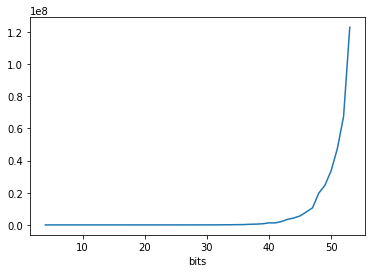

In [3]:
# Calculate the average "elapsed" value for each group of "bits"
avg_elapsed = df.groupby('bits')['elapsed'].mean()

# Plot the result
avg_elapsed.plot()

In [4]:
df = pd.read_csv("spysgx_discret_log.csv")
df.columns = "bits gen prime x y elapsed".split()
# Calculate the average "elapsed" value for each group of "bits"
spysgx_avg_elapsed = df.groupby('bits')['elapsed'].mean()


In [5]:
df = pd.read_csv("bruteforce.csv")
df.columns = "bits gen prime x y elapsed".split()
# Calculate the average "elapsed" value for each group of "bits"
bruteforce_avg_elapsed = df.groupby('bits')['elapsed'].mean()


In [6]:
df = pd.read_csv("spysgx_no_trace_discret_log.csv")
df.columns = "bits gen prime x y elapsed".split()
# Calculate the average "elapsed" value for each group of "bits"
spysgx_no_trace_elapsed = df.groupby('bits')['elapsed'].mean()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


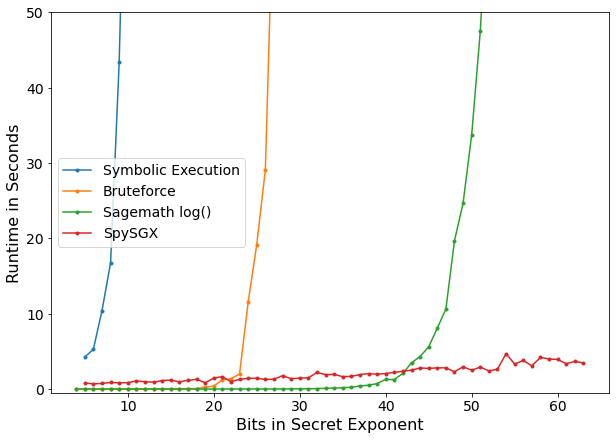

In [21]:
with plt.style.context("arend.mplstyle"):
    
    
    (spysgx_no_trace_elapsed/ 10**6).plot(style='.-')
    (bruteforce_avg_elapsed/ 10**6).plot(style='.-')
    (avg_elapsed / 10**6).plot(style='.-')
    ax = (spysgx_avg_elapsed/ 10**6).plot(style='.-')
    ax.set_ylabel("Runtime in Seconds")
    ax.set_xlabel("Bits in Secret Exponent")
    ax.set_ylim(-.5, 50)
    ax.legend(["Symbolic Execution", "Bruteforce", "Sagemath log()", "SpySGX"])
    fig = ax.figure
    fig.savefig("results_square_mult.pdf")
    fig.savefig("results_square_mult.eps")
    
    #ax.set_yticks(list(range(0, int(avg_elapsed.max()), 10**7)))